# Compare volume changes from RTS-DTM with shoreline changes from CASSIE

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import pandas as pd
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt

from coastal_data import CD_geometry, CD_statistics

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
epsg = 4326
epsg_local = 32618

In [3]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 23
BIGGER_SIZE = 25

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Paths

In [4]:
# path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_rtsdtm = path_to_data_folder+'22_23_Duck_DEM/output/'
path_slcassie = path_to_data_folder + '14_24_34_RS_shoreline_changes/output/'

## Data

In [5]:
poly_target_red = pickle.load(open(path_rtsdtm + f'poly_target_red_{epsg}.pkl', 'rb'))
poly_target_red = CD_geometry.transform_polygon(poly_target_red, epsg, epsg_local)

In [6]:
# CASSIE shoreline changes
cd_tcorr = pickle.load(open(path_slcassie+'cd_tcorr_Duck.pkl', 'rb'))
c_dates = pickle.load(open(path_slcassie+'c_dates_Duck.pkl', 'rb'))
transects = pickle.load(open(path_slcassie+'transects_Duck.pkl', 'rb'))
transects = transects.set_crs(epsg_local)

In [7]:
# RTS-DTM volume changes
volumes = pickle.load(open(path_rtsdtm+'volumes.pkl', 'rb'))

## Correlation
V2: Compute statistics for each transect (no spatial averaging before)  
e.g. correlation between cross-shore time series of each transect against one volume change time series  

In [8]:
cd_tcorr_df = pd.DataFrame.from_dict(cd_tcorr).set_index(c_dates)
cd_tcorr_yearly_av = cd_tcorr_df.groupby(pd.Grouper(freq='YE')).mean()
cd_tcorr_yearly_av = cd_tcorr_yearly_av.set_index(cd_tcorr_yearly_av.index.year)
cd_tcorr_yearly_av = cd_tcorr_yearly_av.drop([1992, 2012])

In [9]:
# Correlation for each transect
corr = pd.DataFrame(columns=volumes.columns, index=cd_tcorr_yearly_av.columns)

for transect in cd_tcorr_yearly_av.columns:
    for col in corr.columns:
        not_nan = np.logical_or(cd_tcorr_yearly_av[transect].isna(), volumes[col].isna())
        corr.loc[transect, col], _ = stats.pearsonr(cd_tcorr_yearly_av.loc[~not_nan, transect], volumes.loc[~not_nan, col])
        # corr.loc[transect, col], _ = stats.spearmanr(cd_tcorr_yearly_av.loc[~not_nan, transect], volumes.loc[~not_nan, col])

In [10]:
idx_all = transects.reset_index(drop=True).intersects(poly_target_red)

In [11]:
c_vali = 'grey'
c_kf = 'brown'
c_rts = 'orange'

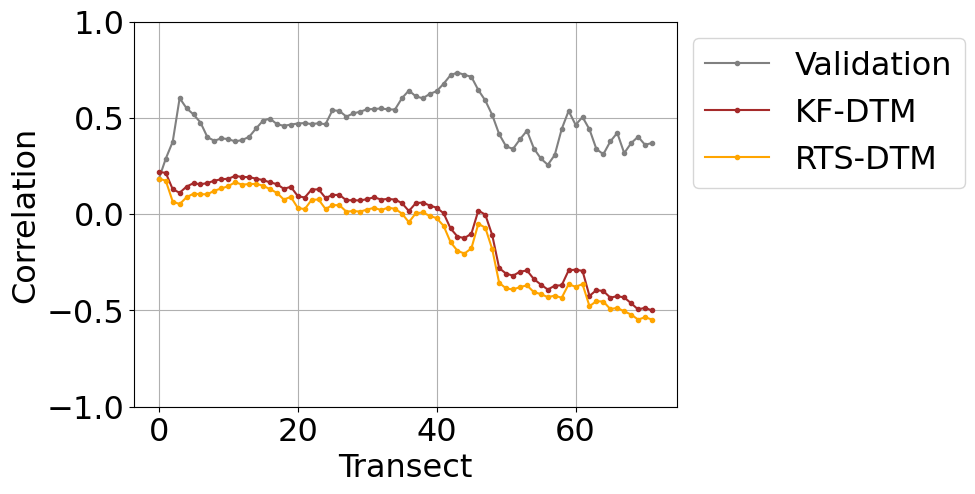

In [17]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(corr.loc[idx_all, f'vali'], '.-', c=c_vali, label='Validation')
ax.plot(corr.loc[idx_all, f'kf'], '.-', c=c_kf, label='KF-DTM')
ax.plot(corr.loc[idx_all, f'rts'], '.-', c=c_rts, label='RTS-DTM')
ax.legend(bbox_to_anchor=(1,1))
ax.set_xlabel('Transect')
ax.set_ylabel('Correlation')
ax.set_ylim([-1,1])
ax.grid()
plt.savefig(f'{path_rtsdtm}Duck_cassie_vs_volumes.png', dpi=300, bbox_inches='tight')

## Trends

In [13]:
trends_cassie = pd.DataFrame(columns=['trend'], index=cd_tcorr_yearly_av.columns)

for transect in cd_tcorr_yearly_av.columns:
    if cd_tcorr_yearly_av[transect].isna().sum() > len(cd_tcorr_yearly_av-5): # min 4 non-nan values
        continue
    trends_cassie.loc[transect, 'trend'], _, _ = CD_statistics.compute_trend_with_error(cd_tcorr_yearly_av.index.values, cd_tcorr_yearly_av[transect])

In [14]:
trends_vol = pd.DataFrame(index=volumes.columns)
for col in volumes.columns:
    trends_vol.loc[col, 'trend'], _, _ = CD_statistics.compute_trend_with_error(volumes.index.values, volumes[col].values)

In [15]:
print('Mean trends CASSIE cross-shore shoreline time series:')
mean_entire = trends_cassie.loc[idx_all,'trend'].mean()
print(f'Entire coastline: {round(mean_entire,2)} m/year')

Mean trends CASSIE cross-shore shoreline time series:
Entire coastline: -0.61 m/year


Visualise volume change trends compared to shoreline change trends? Maybe could place the volume trend histograms at the approximate location in the graph below, and mark the end of each section  
But then could also just compare the numbers, negative/positive, magnitudes of the sections compared to each other  

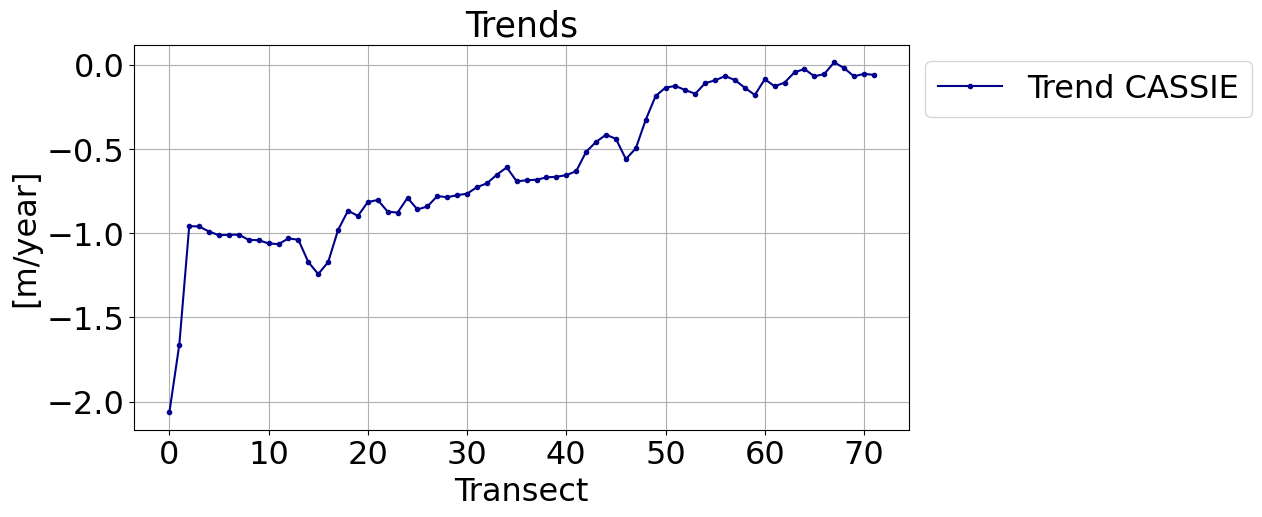

In [16]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(trends_cassie['trend'], '.-', c='darkblue', label='Trend CASSIE')
# ax.hlines(trends_vol.loc['jarkus_all'], trends_cassie.index[0], trends_cassie.index[-1])
ax.set_xlabel('Transect')
ax.set_ylabel('[m/year]')
ax.set_title('Trends')
ax.legend(bbox_to_anchor=(1,1))
ax.grid()